# 04 - Statistical Analysis

This notebook applies formal statistical methods to the cleaned dataset:
descriptive statistics, normality tests, hypothesis tests (t-test, ANOVA,
Mann-Whitney U, Kruskal-Wallis, Chi-square), and correlation analysis.

## 1. Imports and Load Data

In [31]:
import warnings
import numpy as np
import pandas as pd
import scipy.stats as st
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4f}".format)

ALPHA = 0.05  # significance level for all hypothesis tests

# Restore cleaned dataframe
%store -r df_clean
df = df_clean.copy()
print(f"df_clean loaded: {df.shape}")

num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include="object").columns.tolist()
print(f"Numeric columns    : {len(num_cols)}")
print(f"Categorical columns: {len(cat_cols)}")

df_clean loaded: (100000, 48)
Numeric columns    : 38
Categorical columns: 10


---
## 2. Descriptive Statistics

### 2.1 Full describe() for Numeric Columns

In [32]:
desc = df[num_cols].describe().T
desc["skewness"] = df[num_cols].skew().round(4)
desc["kurtosis"] = df[num_cols].kurt().round(4)
print("Full descriptive statistics for numeric columns:")
desc

Full descriptive statistics for numeric columns:


,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
student_id,100000.0000,50000.5000,28867.6578,1.0000,25000.7500,50000.5000,75000.2500,100000.0000,0.0000,-1.2000
poverty_rate_percent,100000.0000,26.1827,15.2814,5.2100,13.6600,23.6400,37.9300,62.2800,0.5603,-0.7253
internet_infrastructure_index,100000.0000,60.2127,20.7400,20.7600,43.1300,55.7500,78.9200,94.3900,0.0116,-1.0906
average_internet_speed_mbps,100000.0000,72.6428,65.3907,5.7400,20.4200,45.6300,107.4100,237.9000,1.1283,0.2013
age,100000.0000,19.9946,3.1639,15.0000,17.0000,20.0000,23.0000,25.0000,0.0018,-1.2196
internet_access_hours,100000.0000,5.0137,1.5819,0.6200,3.9100,5.0100,6.1100,9.4000,0.0032,-0.2660
academic_motivation,100000.0000,5.3859,1.7440,1.0000,4.2300,5.4500,6.6100,10.0000,-0.1708,-0.2152
online_learning_hours,100000.0000,6.3160,1.8466,1.2900,5.0700,6.3500,7.5900,11.3600,-0.0724,-0.1917
social_media_hours,100000.0000,3.3593,1.2827,0.0000,2.4600,3.2900,4.2000,6.8100,0.2375,-0.1661
sessions_per_day,100000.0000,9.8957,3.3573,1.0000,7.5400,9.7400,12.1100,18.9500,0.2057,-0.1661


### 2.2 Frequency Tables for Categorical Columns

In [33]:
for col in cat_cols:
    freq = df[col].value_counts().reset_index()
    freq.columns = [col, "count"]
    freq["percent"] = (freq["count"] / len(df) * 100).round(2)
    print(f"\n--- Frequency table: {col} ---")
    print(freq.to_string(index=False))


--- Frequency table: country ---
     country  count  percent
     Bolivia   2085   2.0800
       Qatar   2065   2.0700
        Peru   2060   2.0600
 New Zealand   2055   2.0500
    Malaysia   2053   2.0500
   Indonesia   2052   2.0500
      France   2050   2.0500
  Kazakhstan   2047   2.0500
     Nigeria   2046   2.0500
      Norway   2044   2.0400
    Thailand   2040   2.0400
  Bangladesh   2039   2.0400
   Argentina   2037   2.0400
       India   2035   2.0400
    Cambodia   2034   2.0300
    Pakistan   2031   2.0300
   Sri Lanka   2030   2.0300
   Singapore   2021   2.0200
       Ghana   2017   2.0200
       China   2016   2.0200
         USA   2015   2.0200
      Turkey   2014   2.0100
     Denmark   2013   2.0100
      Canada   2006   2.0100
 Philippines   2006   2.0100
Saudi Arabia   2005   2.0000
       Japan   2003   2.0000
      Kuwait   2003   2.0000
       Chile   1994   1.9900
 Switzerland   1994   1.9900
        Oman   1991   1.9900
          UK   1990   1.9900
       Ne

---
## 3. Correlation Analysis

### 3.1 Pearson Correlation Matrix

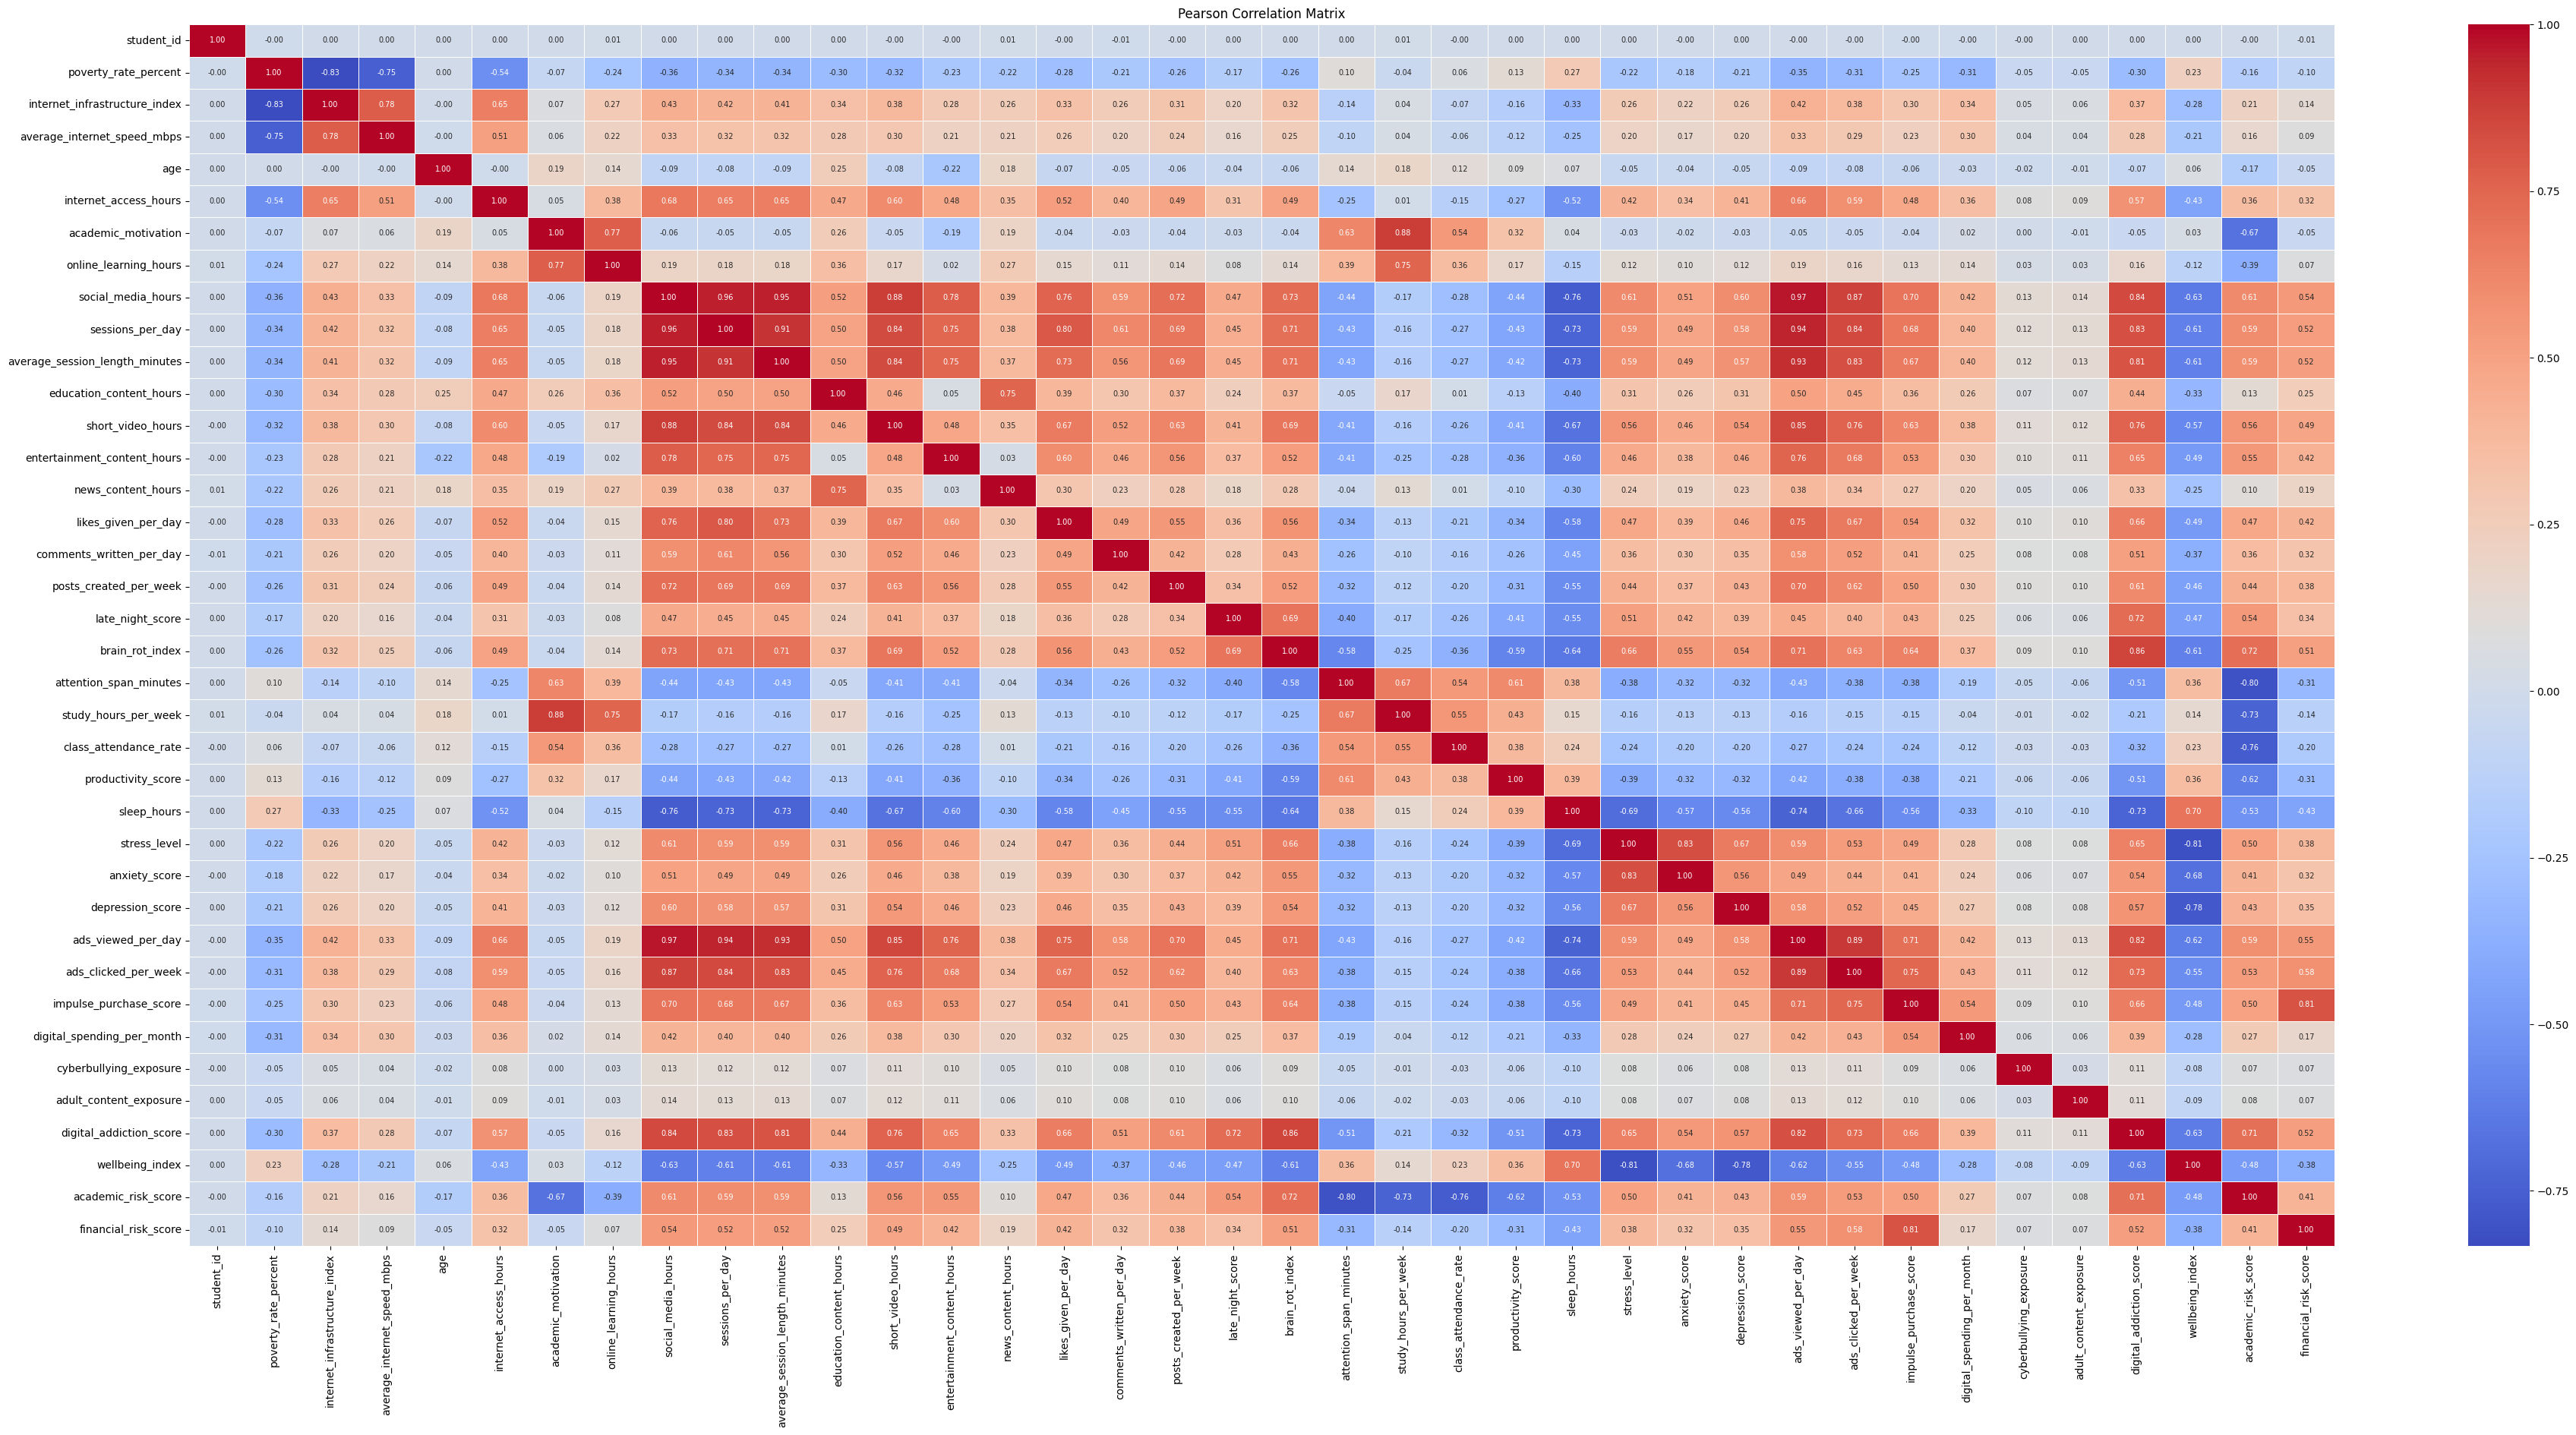

In [38]:
pearson_corr = df[num_cols].corr(method="pearson").round(4)

fig, ax = plt.subplots(figsize=(max(12, len(num_cols)), max(8, len(num_cols) // 2)))
sns.heatmap(pearson_corr, annot=True, fmt=".2f", cmap="coolwarm",
            linewidths=0.4, ax=ax, annot_kws={"size": 7})
ax.set_title("Pearson Correlation Matrix")
plt.tight_layout()
plt.show()

### 3.2 Spearman Correlation Matrix

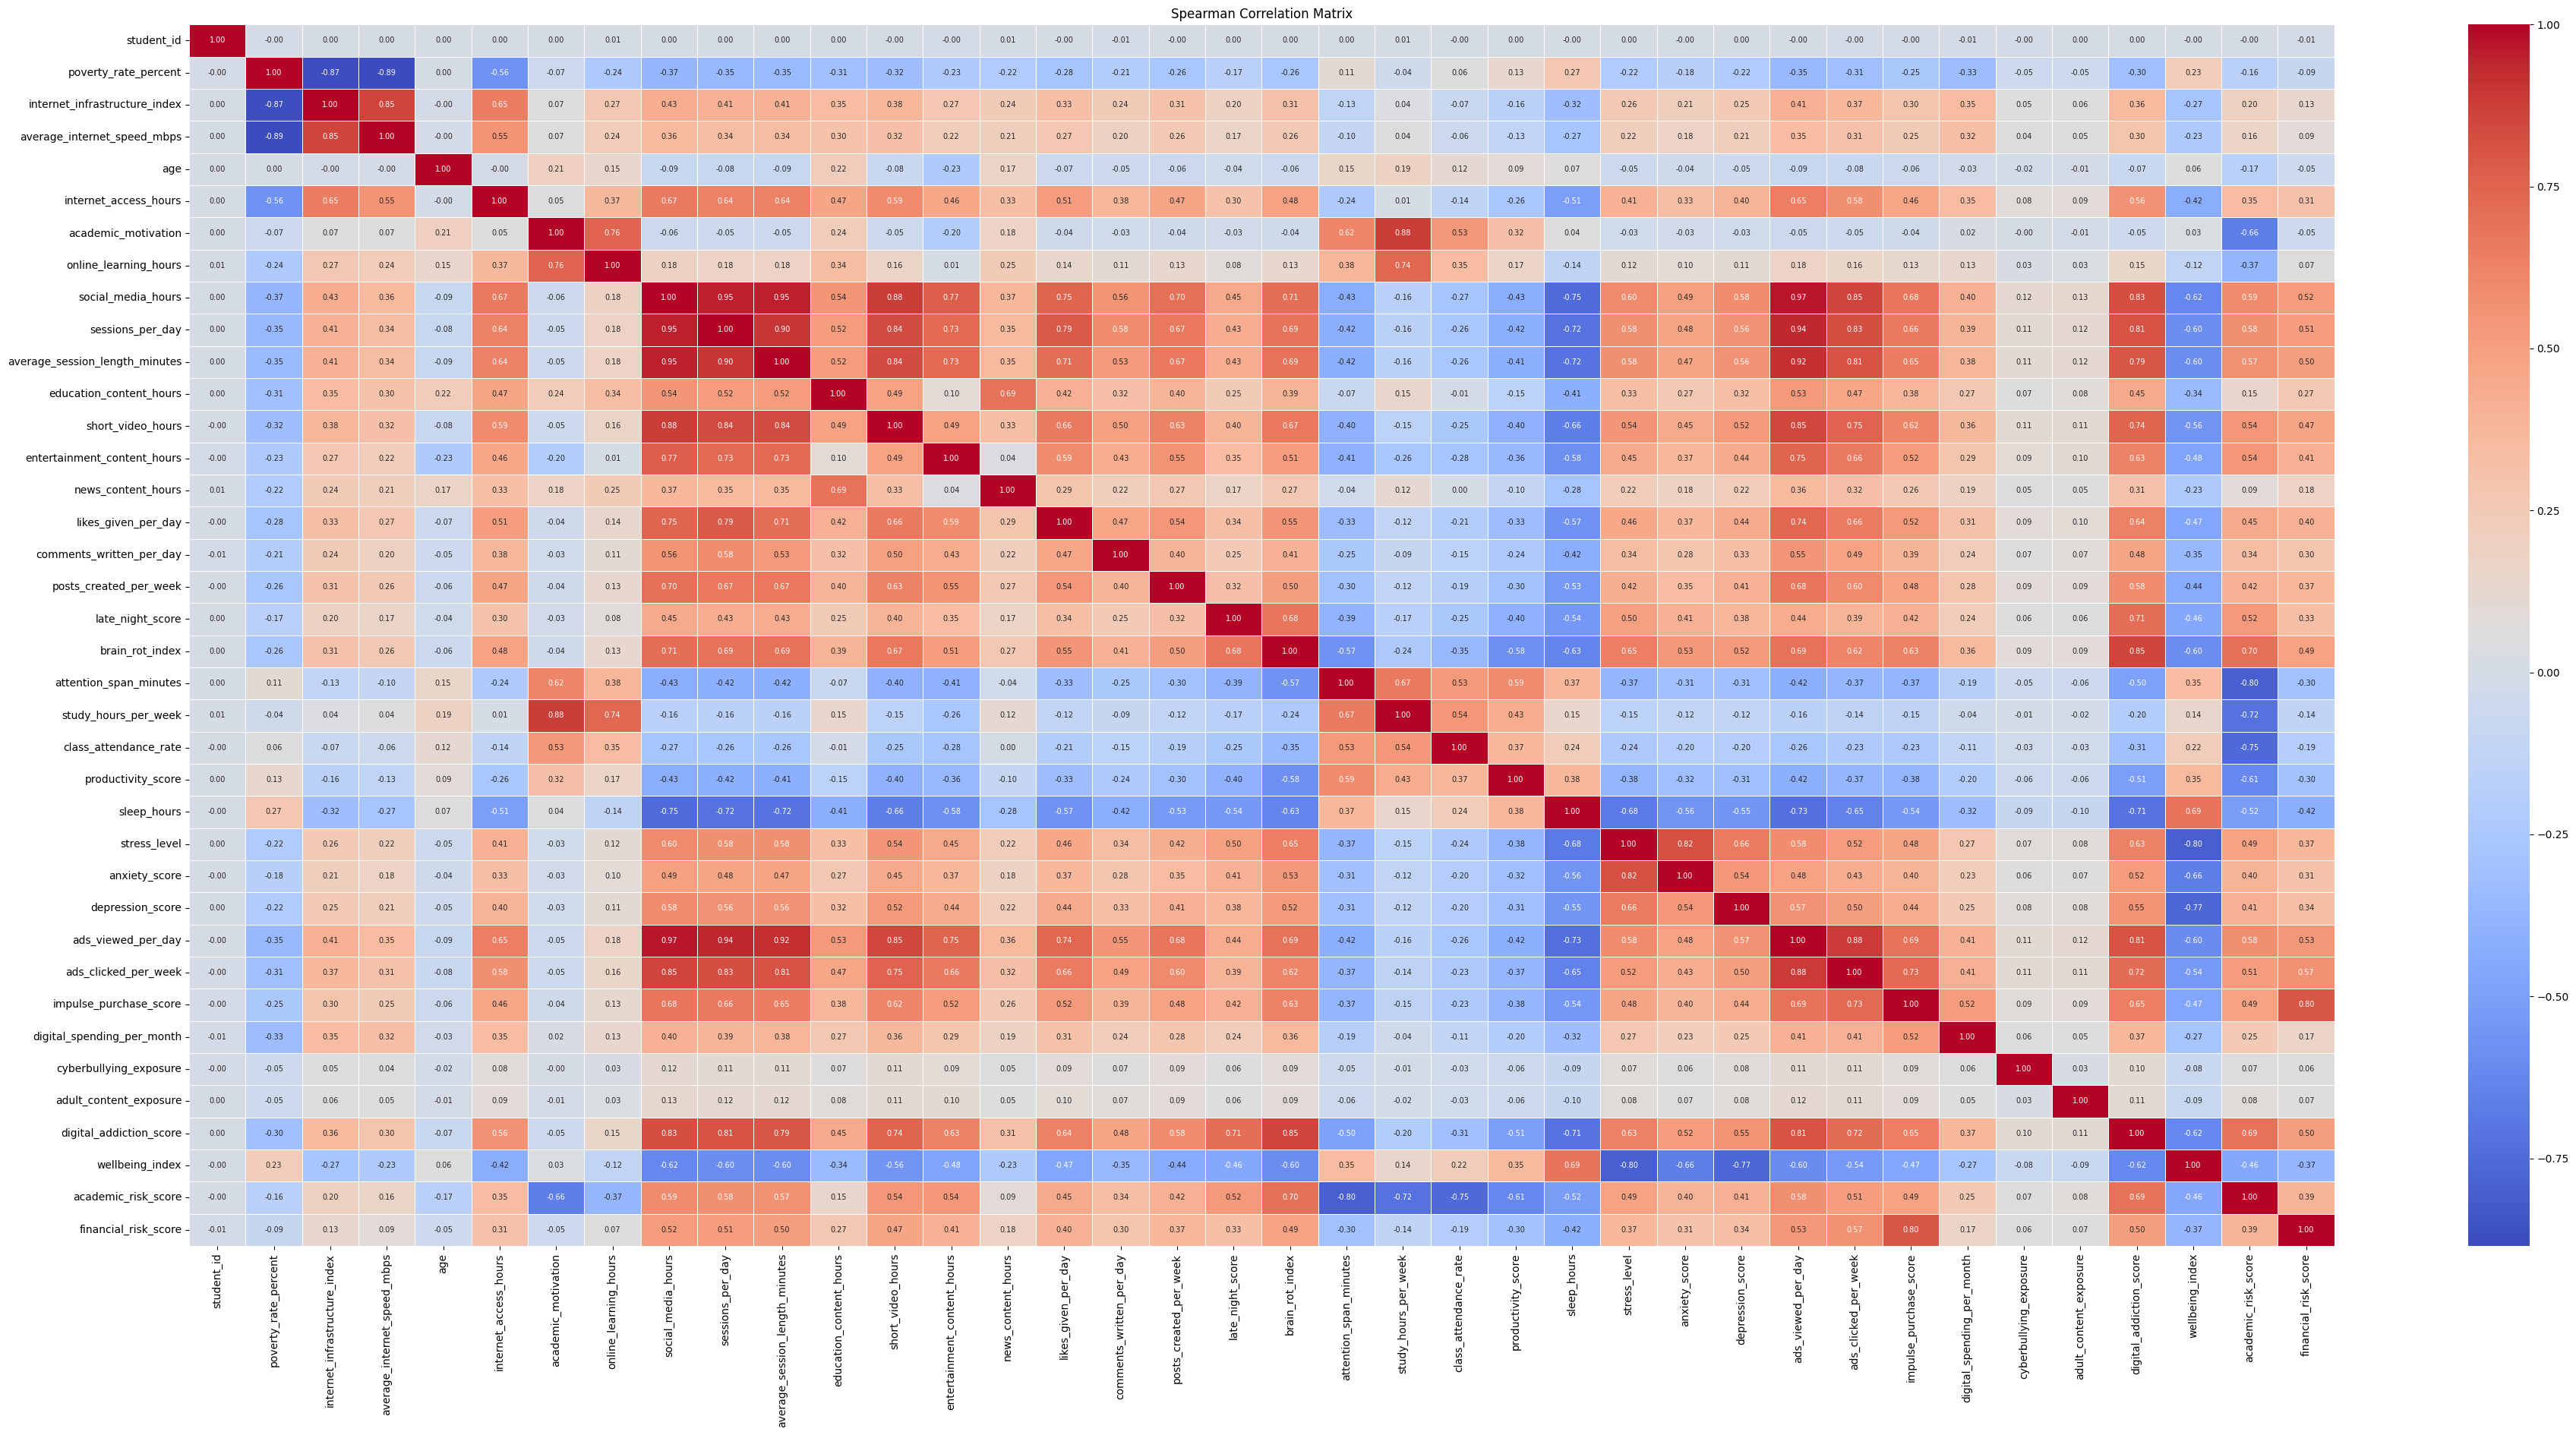

In [39]:
spearman_corr = df[num_cols].corr(method="spearman").round(4)

fig, ax = plt.subplots(figsize=(max(12, len(num_cols)), max(8, len(num_cols) // 2)))
sns.heatmap(spearman_corr, annot=True, fmt=".2f", cmap="coolwarm",
            linewidths=0.4, ax=ax, annot_kws={"size": 7})
ax.set_title("Spearman Correlation Matrix")
plt.tight_layout()
plt.show()

### 3.3 Flag Strongly Correlated Pairs (|r| > 0.7)

In [40]:
def flag_strong_pairs(corr_matrix: pd.DataFrame, threshold: float = 0.7, label: str = "Pearson"):
    """Print pairs where the absolute correlation exceeds the threshold."""
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    strong = (
        upper.stack()
             .reset_index()
             .rename(columns={"level_0": "col_a", "level_1": "col_b", 0: "r"})
    )
    strong = strong[strong["r"].abs() >= threshold].copy()
    strong["r"] = strong["r"].round(4)
    strong = strong.sort_values("r", key=abs, ascending=False)

    print(f"\n{label} — pairs with |r| >= {threshold}:")
    if strong.empty:
        print("  None found.")
    else:
        print(strong.to_string(index=False))


flag_strong_pairs(pearson_corr,  label="Pearson")
flag_strong_pairs(spearman_corr, label="Spearman")


Pearson — pairs with |r| >= 0.7:
                         col_a                          col_b       r
            social_media_hours             ads_viewed_per_day  0.9688
            social_media_hours               sessions_per_day  0.9555
            social_media_hours average_session_length_minutes  0.9548
              sessions_per_day             ads_viewed_per_day  0.9432
average_session_length_minutes             ads_viewed_per_day  0.9251
              sessions_per_day average_session_length_minutes  0.9126
            ads_viewed_per_day           ads_clicked_per_week  0.8937
           academic_motivation           study_hours_per_week  0.8849
            social_media_hours              short_video_hours  0.8826
            social_media_hours           ads_clicked_per_week  0.8659
               brain_rot_index        digital_addiction_score  0.8619
             short_video_hours             ads_viewed_per_day  0.8546
            social_media_hours        digital_addiction_

---
## Summary

- Descriptive stats computed with skewness and kurtosis added to `describe()`.
- Frequency tables printed for all categorical columns.
- Pearson and Spearman correlation matrices visualized; strongly correlated pairs flagged (|r| > 0.7).